In [4]:
from sagemaker.inputs     import TrainingInput
from sagemaker.tensorflow import TensorFlow
import sagemaker
import boto3
 

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/drew/.config/sagemaker/config.yaml


In [7]:
sagemaker_session = sagemaker.Session()

In [11]:
sagemaker.get_execution_role(sagemaker_session,use_default=True)

Couldn't call 'get_role' to get Role ARN from role name Drew to get Role path.
Using default role: AmazonSageMaker-DefaultRole


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 sagemaker.get_execution_role(sagemaker_session,use_default=True)                             │
│   2                                                                                              │
│                                                                                                  │
│ /home/drew/FL-with-MIMIC/.venv/lib/python3.12/site-packages/sagemaker/session.py:8277 in         │
│ get_execution_role                                                                               │
│                                                                                                  │
│   8274 │   │   )                                                                                 │
│   8275 │   │   iam_client = boto3_session.client("iam")                                          │
│   8276 │   │   try:                                                                              │
│ ❱ 8277 │   │   │   iam_client.get_role(RoleName=default_role_name)                               │
│   8278 │   │   except iam_client.exceptions.NoSuchEntityException:                               │
│   8279 │   │   │   iam_client.create_role(                                                       │
│   8280 │   │   │   │   RoleName=default_role_name, AssumeRolePolicyDocument=str(permissions_pol  │
│                                                                                                  │
│ /home/drew/FL-with-MIMIC/.venv/lib/python3.12/site-packages/botocore/client.py:602 in _api_call  │
│                                                                                                  │
│    599 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    600 │   │   │   │   )                                                                         │
│    601 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  602 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    603 │   │                                                                                     │
│    604 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    605                                                                                           │
│                                                                                                  │
│ /home/drew/FL-with-MIMIC/.venv/lib/python3.12/site-packages/botocore/context.py:123 in wrapper   │
│                                                                                                  │
│   120 │   │   │   with start_as_current_context():                                               │
│   121 │   │   │   │   if hook:                                                                   │
│   122 │   │   │   │   │   hook()                                                                 │
│ ❱ 123 │   │   │   │   return func(*args, **kwargs)                                               │
│   124 │   │                                                                                      │
│   125 │   │   return wrapper                                                                     │
│   126                                                                                            │
│                                                                                                  │
│ /home/drew/FL-with-MIMIC/.venv/lib/python3.12/site-packages/botocore/client.py:1078 in           │
│ _make_api_call                                                                                   │
│                                                            

In [8]:
role = sagemaker.get_execution_role() 

Couldn't call 'get_role' to get Role ARN from role name Drew to get Role path.


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 role = sagemaker.get_execution_role()                                                        │
│   2                                                                                              │
│                                                                                                  │
│ /home/drew/FL-with-MIMIC/.venv/lib/python3.12/site-packages/sagemaker/session.py:8295 in         │
│ get_execution_role                                                                               │
│                                                                                                  │
│   8292 │   │   "The current AWS identity is not a role: {}, therefore it cannot be used as a "   │
│   8293 │   │   "SageMaker execution role"                                                        │
│   8294 │   )                                                                                     │
│ ❱ 8295 │   raise ValueError(message.format(arn))                                                 │
│   8296                                                                                           │
│   8297                                                                                           │
│   8298 def generate_default_sagemaker_bucket_name(boto_session):                                 │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ValueError: The current AWS identity is not a role: arn:aws:iam::762568382963:user/Drew, therefore it cannot be 
used as a SageMaker execution role

---

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.datasets import make_multilabel_classification
from sklearn.metrics  import classification_report
from sklearn.manifold import TSNE
from train_eval       import eval_model, train_model
from tqdm             import tqdm

import matplotlib.pyplot   as plt
import torch.nn as nn
import torch

torch.manual_seed(seed = 42)
device = torch.device("cpu") #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Device", device)

Device cpu


In [2]:
X, y = make_multilabel_classification(n_features      = 10,
                                      n_samples       = 40,
                                      length          = 20,
                                      n_classes       = 3,
                                      n_labels        = 1,
                                      allow_unlabeled = False,
                                      random_state    = 42)
print(X.shape)
print(y.shape)
print(y[0])
print(X[0])

(40, 10)
(40, 3)
[1 1 1]
[1. 1. 2. 0. 1. 2. 1. 1. 3. 2.]


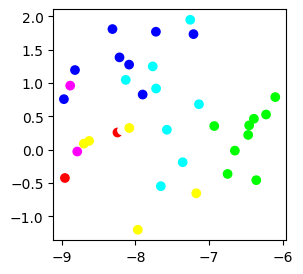

In [3]:
embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
plt.figure(figsize=(3,3))
plt.scatter(embedded[:,0],embedded[:,1],c=y)
plt.show()

In [ ]:
train, val, test = random_split(TensorDataset(torch.from_numpy(X).type(torch.float32),torch.from_numpy(y).type(torch.float32)), lengths=[0.6,0.2,0.2])

c1, c2, c3 = random_split(train,lengths=[0.33,0.33,0.34])
c1_loader  = DataLoader(c1, batch_size = 10, shuffle = True)
c2_loader  = DataLoader(c2, batch_size = 10, shuffle = True)
c3_loader  = DataLoader(c3, batch_size = 10, shuffle = True)

val_loader  = DataLoader(val , batch_size = 10, shuffle = True)
test_loader = DataLoader(test, batch_size = 10, shuffle = True)

In [ ]:
def generate_model():
    model = nn.Sequential(
        nn.Linear(10, 100),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(100, 3),
        nn.Sigmoid()
    )
    return model
model = generate_model()
model.to(device)


loss_module = torch.nn.BCELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99))

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

hist = train_model(model       = model,
                   device      = device,
                   data_loader = c1,
                   num_epochs  = 10)

plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()
plt.show()

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

---

In [ ]:
def server_aggregate(global_model: dict, client_state_dicts: list[dict]) -> nn.Module:
    for key in global_model.keys():
        stacked = torch.stack([client_dict[key].float() for client_dict in client_state_dicts], dim=0)
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [ ]:
def train_model(model,device ,data_loader, num_epochs=100):
    model.train()
    train_losses  = []
    loss_module = torch.nn.BCELoss()
    optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99))
    for epoch in (range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [ ]:
global_model = generate_model()
c1 = generate_model()
c2 = generate_model()
c3 = generate_model()

updated_weights = server_aggregate(global_model.state_dict(),
                                   [c1.state_dict(),c2.state_dict(),c3.state_dict()])

In [ ]:
_ = train_model(model = c1, device=device, data_loader=c1_loader, num_epochs=2)
_ = train_model(model = c2, device=device, data_loader=c1_loader, num_epochs=2)
_ = train_model(model = c3, device=device, data_loader=c1_loader, num_epochs=2)

In [ ]:
updated_weights = server_aggregate(global_model.state_dict(),[c1.state_dict(),c2.state_dict(),c3.state_dict()])

In [ ]:
global_model.load_state_dict(updated_weights)